In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
normalized_data_path = '/content/drive/MyDrive/HALE-Data/normalized.csv'  # Replace with the actual path to your normalized dataset
normalized_data = pd.read_csv(normalized_data_path)

In [ ]:
# Define the feature set (X) and the target variable (y), this time including HALE_Birth
X = normalized_data.drop(columns=['HALE_60'])  # Drop only the target column (HALE_60)
y = normalized_data['HALE_60']  # Define the target variable (HALE at Age 60)

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model_results = {}

In [ ]:
# 1. Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_train_pred_lr = lr_model.predict(X_train)
y_test_pred_lr = lr_model.predict(X_test)
mse_train_lr = mean_squared_error(y_train, y_train_pred_lr)
r2_train_lr = r2_score(y_train, y_train_pred_lr)
mse_test_lr = mean_squared_error(y_test, y_test_pred_lr)
r2_test_lr = r2_score(y_test, y_test_pred_lr)
model_results['Linear Regression'] = {
    'Train MSE': mse_train_lr, 'Train R²': r2_train_lr,
    'Test MSE': mse_test_lr, 'Test R²': r2_test_lr
}

print("Linear Regression:")
print(f"Train MSE: {mse_train_lr}, Train R²: {r2_train_lr}")
print(f"Test MSE: {mse_test_lr}, Test R²: {r2_test_lr}")



Linear Regression:
Train MSE: 0.013904669777231484, Train R²: 0.9861275168215987
Test MSE: 0.012974157103786866, Test R²: 0.98690418899035


In [ ]:
#2. Lasso Regression
from sklearn.linear_model import Lasso
lasso_model = Lasso(alpha=0.1) # Adjust alpha as needed
lasso_model.fit(X_train, y_train)

mse_train_lasso = mean_squared_error(y_train, lasso_model.predict(X_train))
r2_train_lasso = r2_score(y_train, lasso_model.predict(X_train))
mse_test_lasso = mean_squared_error(y_test, lasso_model.predict(X_test))
r2_test_lasso = r2_score(y_test, lasso_model.predict(X_test))
model_results['Lasso Regression'] = {
    'Train MSE': mse_train_lasso, 'Train R²': r2_train_lasso,
    'Test MSE': mse_test_lasso, 'Test R²': r2_test_lasso
}
print("Lasso Regression: ")
print(f"Train R²: {r2_train_lasso:.4f}, Test R²: {r2_test_lasso:.4f}")
print(f"Train MSE: {mse_train_lasso:.4f}, Test MSE: {mse_test_lasso:.4f}")


Lasso Regression: 
Train R²: 0.9215, Test R²: 0.9278
Train MSE: 0.0787, Test MSE: 0.0715


In [ ]:
#3. Ridge Regression
from sklearn.linear_model import Ridge
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

mse_train_ridge = mean_squared_error(y_train, ridge_model.predict(X_train))
r2_train_ridge = r2_score(y_train, ridge_model.predict(X_train))
mse_test_ridge = mean_squared_error(y_test, ridge_model.predict(X_test))
r2_test_ridge = r2_score(y_test, ridge_model.predict(X_test))
model_results['Ridge Regression'] = {
    'Train MSE': mse_train_ridge, 'Train R²': r2_train_ridge,
    'Test MSE': mse_test_ridge, 'Test R²': r2_test_ridge
}
print("Ridge Regression: ")
print(f"Train R²: {r2_train_ridge:.4f}, " f"Test R²: {r2_test_ridge:.4f}")
print(f"Train MSE: {mse_train_ridge:.4f}, " f"Test MSE: {mse_test_ridge:.4f}")


Ridge Regression: 
Train R²: 0.9860, Test R²: 0.9869
Train MSE: 0.0140, Test MSE: 0.0130


In [ ]:
# 4. Random Forest Regressor 
rf_model = RandomForestRegressor(
    n_estimators=50,          
    max_depth=10,             
    min_samples_split=10,     
    oob_score=True,          
    random_state=42           
)

rf_model.fit(X_train, y_train)

y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

mse_train_rf = mean_squared_error(y_train, y_train_pred_rf)
r2_train_rf = r2_score(y_train, y_train_pred_rf)
mse_test_rf = mean_squared_error(y_test, y_test_pred_rf)
r2_test_rf = r2_score(y_test, y_test_pred_rf)

model_results['Random Forest'] = {
    'Train MSE': mse_train_rf,
    'Train R²': r2_train_rf,
    'Test MSE': mse_test_rf,
    'Test R²': r2_test_rf,
}

print("Random Forest Model Results:")
print(f"Train MSE: {mse_train_rf}, Train R²: {r2_train_rf}")
print(f"Test MSE: {mse_test_rf}, Test R²: {r2_test_rf}")

if rf_model.oob_score:
    print(f"OOB Score: {rf_model.oob_score_}")  # OOB Score for generalization check

Random Forest Model Results:
Train MSE: 0.004566207981166695, Train R²: 0.9954443618998028
Test MSE: 0.009383963395670427, Test R²: 0.9905280466262194
OOB Score: 0.9902174232239168


In [ ]:
# 5. Gradient Boosting Regressor
gbr_model = GradientBoostingRegressor(n_estimators=50,random_state=42)
gbr_model.fit(X_train, y_train)
y_train_pred_gbr = gbr_model.predict(X_train)
y_test_pred_gbr = gbr_model.predict(X_test)
mse_train_gbr = mean_squared_error(y_train, y_train_pred_gbr)
r2_train_gbr = r2_score(y_train, y_train_pred_gbr)
mse_test_gbr = mean_squared_error(y_test, y_test_pred_gbr)
r2_test_gbr = r2_score(y_test, y_test_pred_gbr)
model_results['Gradient Boosting'] = {
    'Train MSE': mse_train_gbr, 'Train R²': r2_train_gbr,
    'Test MSE': mse_test_gbr, 'Test R²': r2_test_gbr
}

print("Gradient Boosting Regressor:")
print(f"Train MSE: {mse_train_gbr}, Train R²: {r2_train_gbr}")
print(f"Test MSE: {mse_test_gbr}, Test R²: {r2_test_gbr}")


Gradient Boosting Regressor:
Train MSE: 0.015194277728671672, Train R²: 0.9848408940610653
Test MSE: 0.016611798607472347, Test R²: 0.9832324386583596


In [ ]:
#6. AdaBoost Regressor
from sklearn.ensemble import AdaBoostRegressor
ada_model = AdaBoostRegressor(n_estimators=50, random_state=42)
ada_model.fit(X_train, y_train)

mse_train_ada = mean_squared_error(y_train, ada_model.predict(X_train))
r2_train_ada = r2_score(y_train, ada_model.predict(X_train))
mse_test_ada = mean_squared_error(y_test, ada_model.predict(X_test))
r2_test_ada = r2_score(y_test, ada_model.predict(X_test))
model_results['Adaboost'] = {
    'Train MSE': mse_train_ada, 'Train R²': r2_train_ada,
    'Test MSE': mse_test_ada, 'Test R²': r2_test_ada
}
print("AdaBoost Regressor: ")
print(f"Train R²: {r2_train_ada:.4f}, Test R²: {r2_test_ada:.4f}")
print(f"Train MSE: {mse_train_ada:.4f}, Test MSE: {mse_test_ada:.4f}")


AdaBoost Regressor: 
Train R²: 0.9325, Test R²: 0.9280
Train MSE: 0.0676, Test MSE: 0.0714


In [ ]:
# 7. K-Nearest Neighbors Regressor
knn_model = KNeighborsRegressor()
knn_model.fit(X_train, y_train)
y_train_pred_knn = knn_model.predict(X_train)
y_test_pred_knn = knn_model.predict(X_test)
mse_train_knn = mean_squared_error(y_train, y_train_pred_knn)
r2_train_knn = r2_score(y_train, y_train_pred_knn)
mse_test_knn = mean_squared_error(y_test, y_test_pred_knn)
r2_test_knn = r2_score(y_test, y_test_pred_knn)
model_results['KNN'] = {
    'Train MSE': mse_train_knn, 'Train R²': r2_train_knn,
    'Test MSE': mse_test_knn, 'Test R²': r2_test_knn
}

print("K Neighbors Regressor: ")
print(f"Train MSE: {mse_train_knn}, Train R²: {r2_train_knn}")
print(f"Test MSE: {mse_test_knn}, Test R²: {r2_test_knn}")

K Neighbors Regressor: 
Train MSE: 0.009615175457555747, Train R²: 0.9904070817984664
Test MSE: 0.01698097878920063, Test R²: 0.9828597968096641


In [ ]:
#8. SVR
svr_model = SVR()
svr_model.fit(X_train, y_train)

mse_train_svr = mean_squared_error(y_train, svr_model.predict(X_train))
r2_train_svr = r2_score(y_train, svr_model.predict(X_train))
mse_test_svr = mean_squared_error(y_test, svr_model.predict(X_test))
r2_test_svr = r2_score(y_test, svr_model.predict(X_test))
model_results['SVR'] = {
    'Train MSE': mse_train_svr, 'Train R²': r2_train_svr,
    'Test MSE': mse_test_svr, 'Test R²': r2_test_svr
}
print("SVR:")
print(f"Train R²: {r2_train_svr:.4f}, Test R²: {r2_test_svr:.4f}")
print(f"Train MSE: {mse_train_svr:.4f}, Test MSE: {mse_test_svr:.4f}")


SVR:
Train R²: -0.0326, Test R²: -0.0306
Train MSE: 1.0350, Test MSE: 1.0210


In [ ]:
# Display model comparison results
model_comparison = pd.DataFrame(model_results).T
print(model_comparison)

                   Train MSE  Train R²  Test MSE   Test R²
Linear Regression   0.013905  0.986128  0.012974  0.986904
Random Forest       0.004566  0.995444  0.009384  0.990528
Gradient Boosting   0.015194  0.984841  0.016612  0.983232
KNN                 0.009615  0.990407  0.016981  0.982860
Lasso Regression    0.078669  0.921513  0.071486  0.927844
Ridge Regression    0.014021  0.986011  0.013012  0.986866
Adaboost            0.067639  0.932517  0.071378  0.927952
SVR                 1.035039 -0.032643  1.020993 -0.030567


<Figure size 1000x600 with 0 Axes>

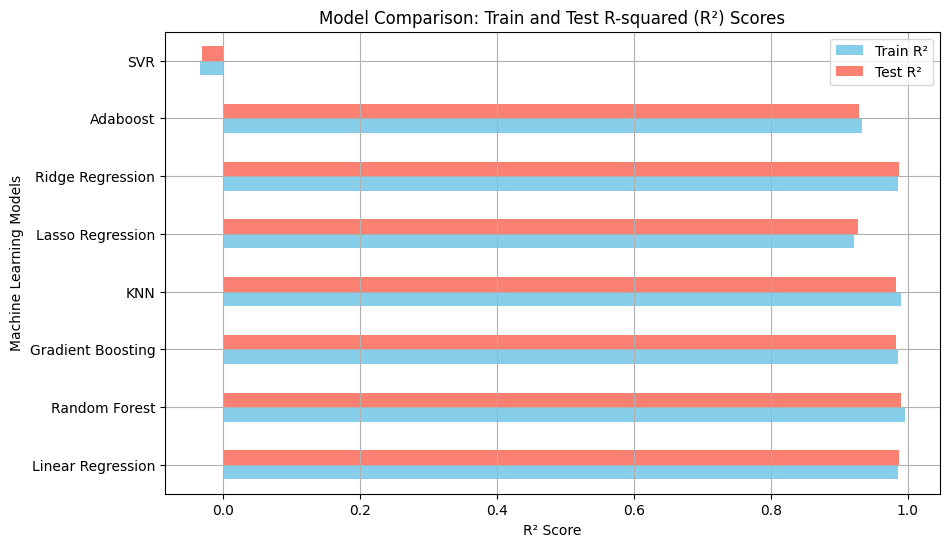

In [ ]:
plt.figure(figsize=(10, 6))
model_comparison[['Train R²', 'Test R²']].plot(kind='barh', figsize=(10, 6), color=['skyblue', 'salmon'])
plt.title("Model Comparison: Train and Test R-squared (R²) Scores")
plt.xlabel("R² Score")
plt.ylabel("Machine Learning Models")
plt.grid(True)
plt.show()

<Figure size 1000x600 with 0 Axes>

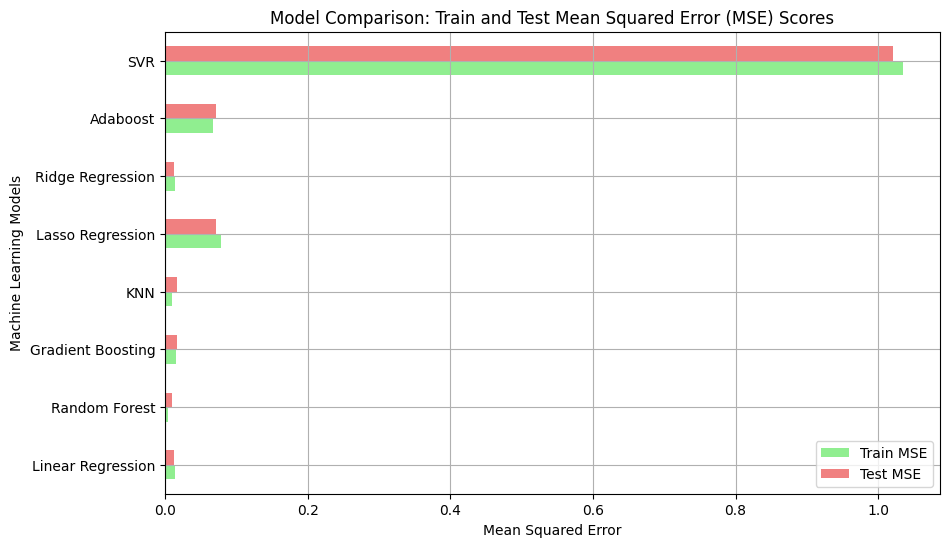

In [ ]:
# Plot comparison of MSE scores for training and test sets
plt.figure(figsize=(10, 6))
model_comparison[['Train MSE', 'Test MSE']].plot(kind='barh', figsize=(10, 6), color=['lightgreen', 'lightcoral'])
plt.title("Model Comparison: Train and Test Mean Squared Error (MSE) Scores")
plt.xlabel("Mean Squared Error")
plt.ylabel("Machine Learning Models")
plt.grid(True)
plt.show()

                                              Feature  Importance
2   infant mortality rate (between birth and 11 mo...    0.709407
1                                          HALE_Birth    0.231173
11                              ParentLocation_Africa    0.015924
5   Probability of dying between the exact ages 30...    0.007055
0                                              Period    0.006347
6   Estimates of rate of homicides (per 100 000 po...    0.005597
10  Prevalence of raised blood pressure among adul...    0.005383
8   Prevalence of insufficient physical activity a...    0.002405
9   Prevalence of obesity among adults, BMI ³ 30 (...    0.002375
3   Age-standardized suicide rates (per 100 000 po...    0.002180


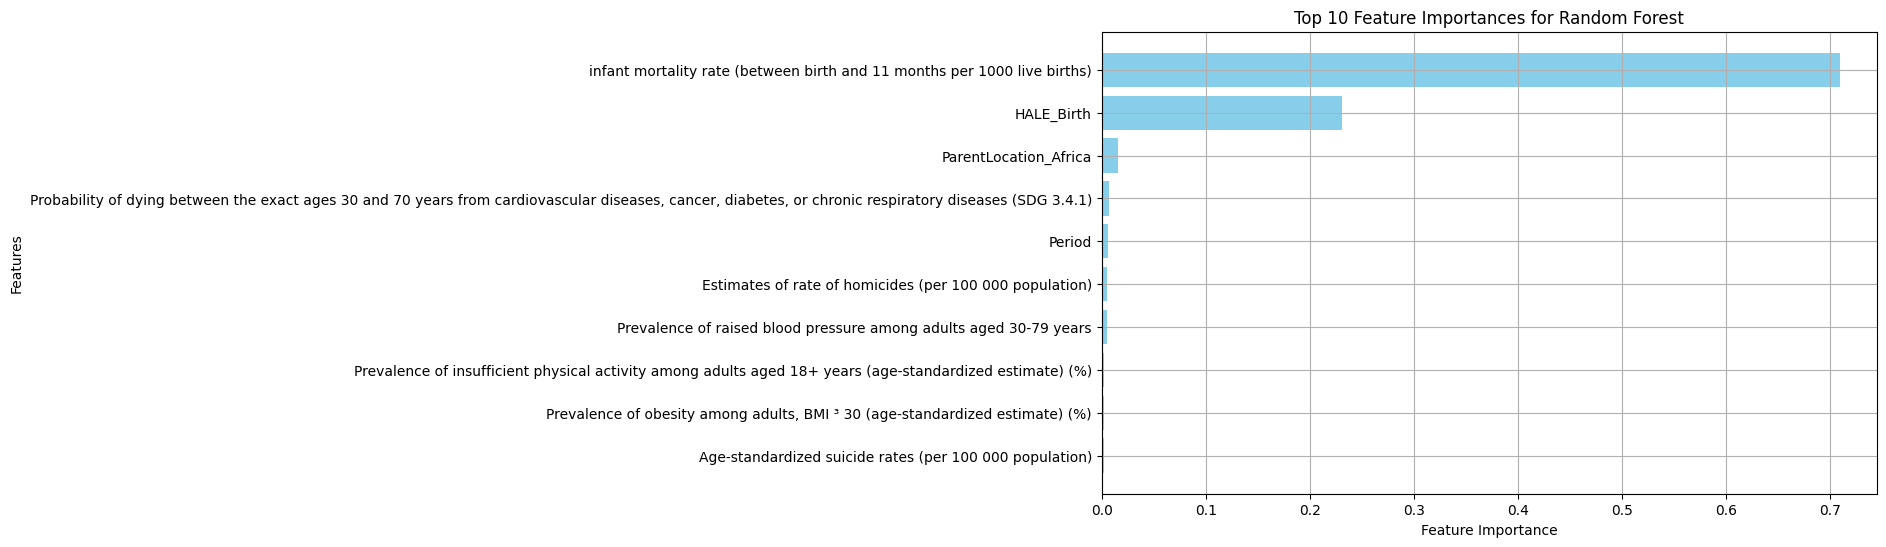

In [ ]:
# Calculate feature importance for Random Forest
rf_feature_importance = rf_model.feature_importances_

# Create a DataFrame to display feature importance
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_feature_importance
}).sort_values(by='Importance', ascending=False)

# Display top 10 most important features
print(feature_importance_df.head(10))

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'][:10], feature_importance_df['Importance'][:10], color='skyblue')
plt.title('Top 10 Feature Importances for Random Forest')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()
